 # <center>Lecture 4:  Balance and Sequentiality in Bayesian Analyses  </center>  
 ## <center>Instructor: Dr. Hu Chuan-Peng  </center>

## 🔍 回顾 Bayes' Rule

在前面的课程中，我们讨论了贝叶斯模型在处理不同类型数据时的应用，包括单一事件、离散变量和连续变量。
现在我们对这些概念再次进行简要的回顾和总结：

| 知识点         | 内容描述                                                                                      | 常用分布                     |
|----------------|---------------------------------------------------------------------------------------------|-----------------------------|
| **单个事件**       | 讨论事件的基本概念，并定义如何计算事件的概率。                                               | 伯努利分布（Bernoulli）         |
| **离散变量**       | 介绍离散随机变量及其常见分布，如二项分布。                                      | 二项分布             |
| **连续变量**       | 探讨连续随机变量及其常见分布，如正态分布和均匀分布。                                      | 正态分布                      |

#### Lecture 4课程大纲：

1. 不同的先验和似然对后验的影响
    - 贝叶斯中的极端先验和主观性
2. 顺序数据在贝叶斯推断中的动态变化
3. 如何通过贝叶斯方法在实际应用中**找到最佳平衡**

## Different priors, different posteriors

**随机点运动任务(Bechdel test)**  

- 随机点运动任务是一个经典的认知任务，是研究感知决策(perceptual decision making)的标准范式。  
- 被试任务：  
   - 被试观察屏幕上的点，这些点以不同的一致性水平随机移动。  
   - 任务是判断这些点的主要移动方向（例如，向左还是向右）。  

<center>  
    <table>  
            <tr>  
                <td><img src="https://cdn.kesci.com/upload/sjwnyi477j.gif?imageView2/0/w/400/h/400" alt=""></td>  
                <td><img src="https://cdn.kesci.com/upload/sjwnyt1yq4.gif?imageView2/0/w/400/h/400" alt=""></td>  
            </tr>  
            <tr>  
                <td>一致性10%</td>  
                <td>一致性60%</td>  
            </tr>  
    </table>  
</center>


正确率与任务难度：  
   - 根据正确率的数据，我们可以使用心理物理曲线描述运动强度（点的一致性百分比）与决策正确率之间的关系。

![image](https://cdn.kesci.com/upload/sjzjcgwjrm.png?imageView2/0/w/640/h/640)  
  
> Shooshtari, S. V., Sadrabadi, J. E., Azizi, Z., & Ebrahimpour, R. (2019). Confidence representation of perceptual decision by EEG and eye data in a random dot motion task. Neuroscience, 406, 510–527. https://doi.org/10.1016/j.neuroscience.2019.03.031  

**不同的先验分布**

在随机点运动任务中，被试正确探测出点的运动方向的取值范围在0-1之间，不同被试、不同条件下的真实的能力不同（与上节课的“重复成功率”类似）。  

- 根据先前的文献(Vafaei Shooshtari et al., 2019)，当随机点的一致性为5%时，个体的正确率约为70%  

  > Shooshtari, S. V., Sadrabadi, J. E., Azizi, Z., & Ebrahimpour, R. (2019). Confidence representation of perceptual decision by EEG and eye data in a random dot motion task. Neuroscience, 406, 510–527. https://doi.org/10.1016/j.neuroscience.2019.03.031  


同时，回顾上节课，我们所建立的关于正确判断的先验分布值为0.6、0.7和0.8三个值。
假设实验者对点的初始位置有自己独特的信念（例如，假设点更可能位于右上象限）。

那么在这节课，我们将一起看一看其他的先验分布的情况。

我们假设正确率为 $\pi$，同时考虑到正确率的范围为0～1，不同的先验可能表现为：

1. 认为$\pi$的估计更可能位于小于0.5的区域  
2. 认为$\pi$的估计更可能接近1  
3. 认为$\pi$可以处于0-1的任何位置  

这就构成了三种与先前不同的先验，我们可以使用不同的Beta分布来表示。  

In [11]:
# 导入必要的库
import scipy.stats as st
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import preliz as pz

from scipy.stats import binom

# 为 preliz 绘图设置图形样式
pz.style.library["preliz-doc"]["figure.dpi"] = 100
pz.style.library["preliz-doc"]["figure.figsize"] = (10, 4)
pz.style.use("preliz-doc")

/var/folders/yk/78rqxlxn4pz_rsb5_31xvh340000gn/T/ipykernel_19508/3611698629.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


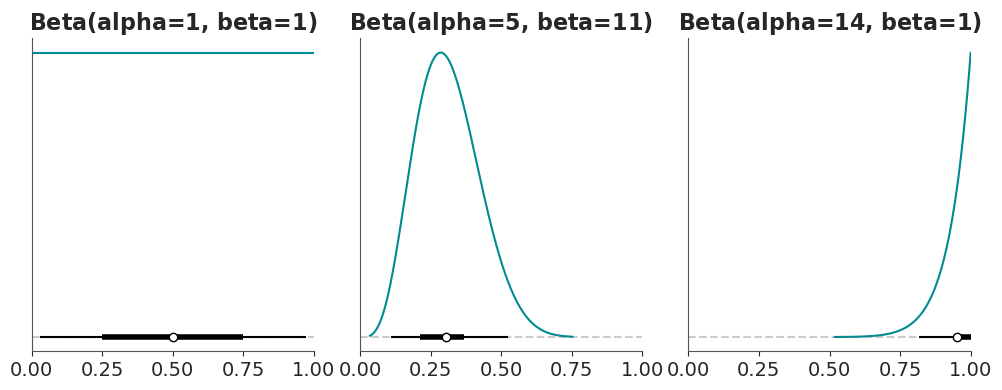

In [12]:
# 创建一个3x3的网格子图，每个子图的尺寸为10x10
fig, axs = plt.subplots(1, 3)

# 绘制 Beta分布的PDF，并显示置信区间
pz.Beta(1, 1).plot_pdf(pointinterval=True, ax=axs[0], legend="title")
pz.Beta(5, 11).plot_pdf(pointinterval=True, ax=axs[1], legend="title")
pz.Beta(14, 1).plot_pdf(pointinterval=True, ax=axs[2], legend="title")

# 设置每个子图的X轴范围为0到1
for ax in axs:
    ax.set_xlim(0, 1)


# 自动调整子图之间的间距，以防止标签重叠
plt.tight_layout()

# 显示绘制的图形
plt.show()

**不同类型的先验**  

我们来回顾一下从先验中我们可以获得什么信息  

* 在上图中，不同的先验，反映了人们对正确率的不同信念(认为$\pi$主要集中分布在哪里)  

* 同时，先验分布的集中程度也反映了人们对某种信念的肯定程度  

比如，对于$Beta(14,1)$这个先验，$\pi$的取值集中分布在0.8-1.0这种“高正确率区域”，说明实验者对被试正确率的信念是很肯定的。  

而对于$Beta(1,1)$这个先验，$\pi$的取值均匀分布在0-1之间，实验者觉得$\pi$取任何值的可能性都是一样的，换言之他们也不知道$\pi$可能是多少。  

figure：Beta(1,1)的图
figure：Beta(14,1)的图

以上两种先验，可被总结为**信息型先验(informative prior)** 和 **模糊型先验(vague prior)** ，其中：  

* **信息型先验**：先验分布比较窄，可变范围小，说明此先验强烈，可以提供比较确定的信息，如$Beta(14,1)$  

* **模糊型先验**：先验分布的可变范围大，无法提供确定的信息，如$Beta(1,1)$

**调查数据**  

在继续探究不同的先验如何影响后验之前，我们还需要一些**数据**  

我们依旧以Evans et al.（2020, Exp. 1） 的数据为例。  

> Evans, N. J., Hawkins, G. E., & Brown, S. D. (2020). The role of passing time in decision-making. Journal of Experimental Psychology: Learning, Memory, and Cognition, 46(2), 316–326. https://doi.org/10.1037/xlm0000725  

In [33]:
import pandas as pd
import numpy as np

# 读取 Evans 研究的数据
# try:
#   Evans = pd.read_csv("/home/mw/input/bayes3797/evans2020JExpPsycholLearn_exp1_full_data.csv")
# except:
#   Evans = pd.read_csv('data/evans2020JExpPsycholLearn_exp1_full_data.csv.csv')
Evans = pd.read_csv('/Users/ss/Documents/PyBayesian/data/evans2020JExpPsycholLearn_exp1_full_data.csv')

# 设置随机数种子以确保结果可复现
np.random.seed(84735)

# 筛选符合条件的数据
Evans_1 = Evans.query('subject == 82111 & percentCoherence == 5')

# 打印前 10 条抽取的数据
Evans_1.head(5)

,subject,blkNum,trlNum,coherentDots,numberofDots,percentCoherence,winningDirection,response,correct,eventCount,averageFrameRate,RT
50897,82111,2,2,2,40,5,right,right,1,30,15.167,1978
50898,82111,2,3,2,40,5,left,left,1,23,15.416,1492
50910,82111,2,15,2,40,5,left,left,1,20,15.848,1262
50921,82111,2,26,2,40,5,left,right,0,66,15.285,4318
50923,82111,2,28,2,40,5,left,right,0,69,15.286,4514


In [34]:
#统计 'binary' 列中各个值的出现次数
Evans_1['correct'].value_counts()

correct
1    152
0    101
Name: count, dtype: int64


根据数据显示，我们看到单个被试在253个试次中有152个试次判断为正确。

### Beta-Binomial 组合

在正确率 $\pi$ 下，某一被试在253个试次中，有152次判断为正确的可能性。这个似然函数可以用**二项分布**来表示：

$$  
Y | \pi  \sim \text{Bin}(n, \pi)  
$$  

似然函数为：

$$  
f(y|\pi) = P(Y=y | \pi) = \binom{253}{152} \pi^{152} (1-\pi)^{101}  
$$  

------------------------

这里，我们的正确率 $\pi$ 服从 **Beta** 分布，似然函数服从**二项分布**：

$$  
Y | \pi  \sim \text{Bin}(n, \pi)  
$$  

$$  
\pi  \sim \text{Beta}(\alpha, \beta)  
$$  

从上一节课我们知道，在这种情况下，**后验分布**仍然是 Beta 分布，并且可以表示为：

$$  
\pi | (Y = y) \sim \text{Beta}(\alpha + y, \beta + n - y)  
$$  

因此，某一被试在253个试次下，有152次判断为正确的情况时，后验分布可以写为：

$$  
\pi | (Y = 152) \sim \text{Beta}(\alpha + 152, \beta + 101)  
$$  

**🤔 思考时间**  

下图画出了三种先验-似然组合，  

我们可以猜测一下，哪一种后验分布的形状和似然分布的形状最为类似：  


<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
/var/folders/yk/78rqxlxn4pz_rsb5_31xvh340000gn/T/ipykernel_19508/3671034215.py:28: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_xlabel('$\pi$')


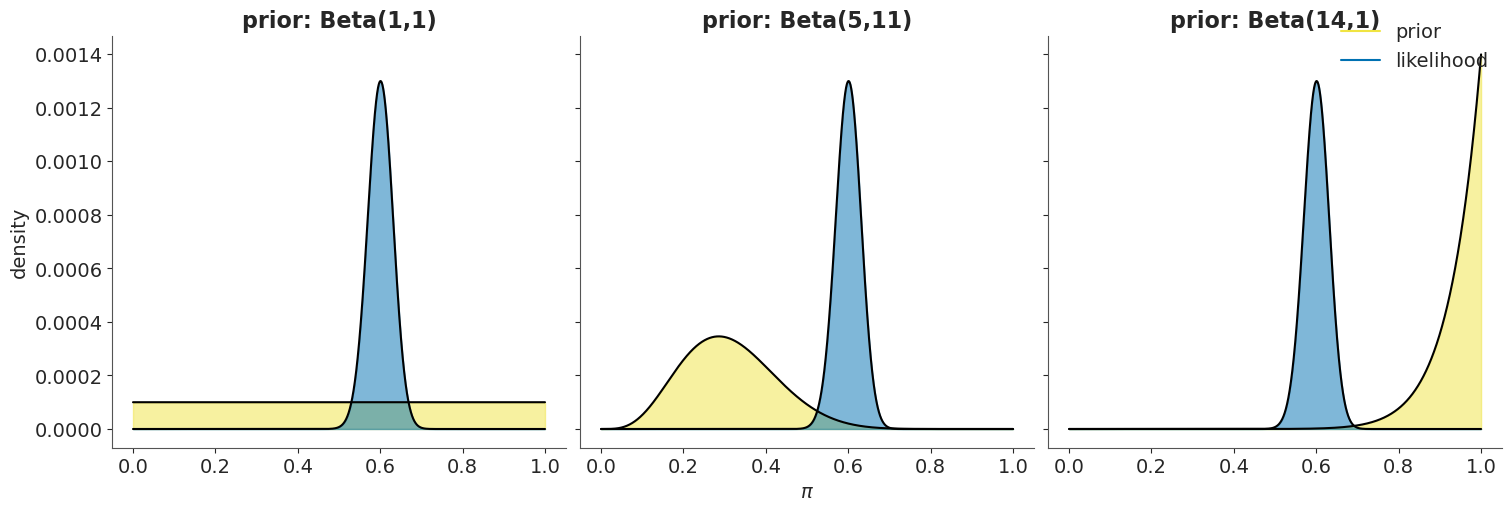

In [35]:
# 定义不同的 Beta 分布参数
params = [(1, 1), (5, 11), (14, 1)]

# 创建一个包含三个子图的画布
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
x = np.linspace(0, 1, 10000)

# 计算二项分布的 likelihood
likelihood_value = st.binom.pmf(152, 253, x) / np.sum(st.binom.pmf(152, 253, x))

# 循环遍历不同的参数组合
for i, (alpha_, beta_) in enumerate(params):
    # 计算 Beta 分布的概率密度函数值
    pdf_values = beta.pdf(x, alpha_, beta_) / np.sum(beta.pdf(x, alpha_, beta_))
    
    # 绘制 Beta 分布的线图
    axes[i].plot(x, pdf_values, color="black")
    axes[i].fill_between(x, pdf_values, color="#f0e442", alpha=0.5)
    
    # 绘制 likelihood 的线图
    axes[i].plot(x, likelihood_value, color="black")
    axes[i].fill_between(x, likelihood_value, color="#0071b2", alpha=0.5)
    
    # 设置子图标题
    axes[i].set_title(f'prior: Beta({alpha_},{beta_})')

# 设置 x 和 y 轴标签
axes[1].set_xlabel('$\pi$')
axes[0].set_ylabel('density')

# 创建自定义图例
custom_lines = [Line2D([], [], color="#f0e442"),
                Line2D([], [], color="#0071b2")]
        
# 将图例放置在子图外部的右上角
fig.legend(custom_lines, ['prior', 'likelihood'], loc='outside upper right', bbox_to_anchor=(1, 1))

# 移除图的上、右边框线
sns.despine()


**后验图示**  

我们可以使用公式来快速得到三种后验的表达式  
$$  
\pi | (Y = y) \sim \text{Beta}(\alpha + y, \beta + n - y)  
$$  

<center>  

|Analyst|Prior  |Posterior  
|----|-----|----|  
|$\alpha$   |Beta(5,11)|Beta(14,22)|  
|$\beta$   |Beta(1,1)|Beta(10,12)|  
|mean   |Beta(14,1) |Beta(23,12)|  

</center>  
	
在表格中，每一行展示了不同被试的先验分布和后验分布。通过结合先验和观测数据，我们得到了相应的后验 Beta 分布。

接下来，我们可以将这些分布可视化，绘制出三种后验分布的图示，以便直观展示更新后的正确率 $\pi$ 分布。
 

<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
/var/folders/yk/78rqxlxn4pz_rsb5_31xvh340000gn/T/ipykernel_19508/2710029079.py:37: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_xlabel('$\pi$')


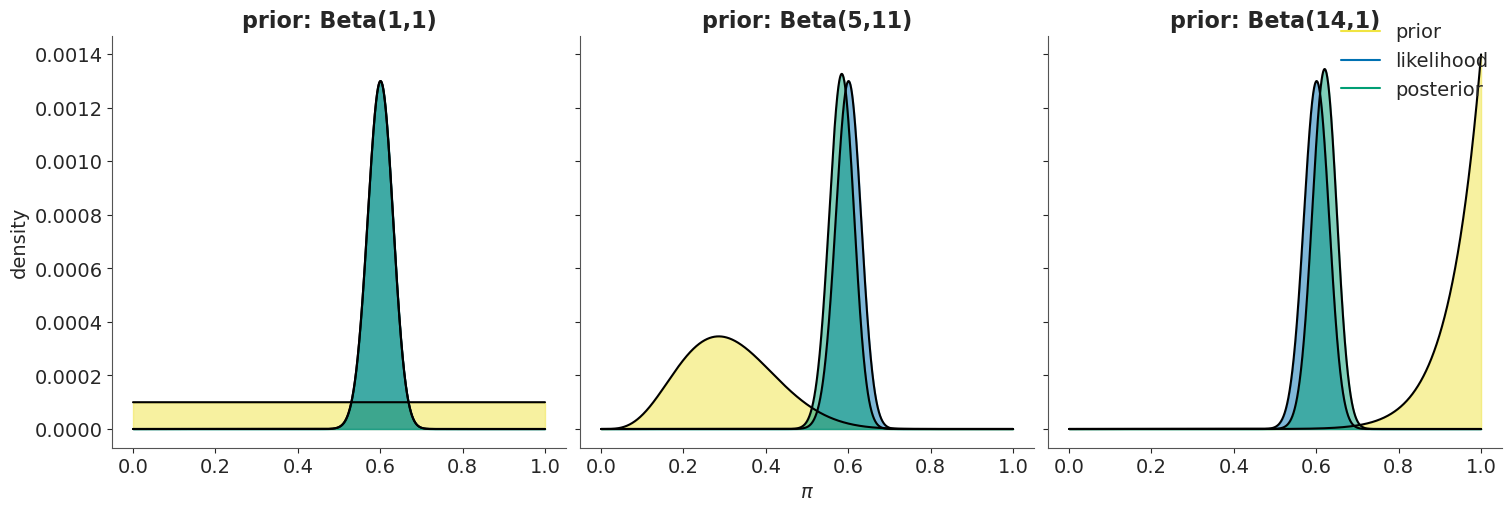

In [36]:
# 定义不同的 Beta 分布参数
params = [(1, 1), (5, 11), (14, 1)]

# 创建一个包含三个子图的画布
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
x = np.linspace(0, 1, 10000)

# 循环遍历不同的参数组合
for i, (alpha_, beta_) in enumerate(params):
    # 计算二项分布的似然值
    likelihood_value = st.binom.pmf(152, 253, x)
    
    # 计算 Beta 分布的概率密度函数值并进行归一化
    pdf_values = beta.pdf(x, alpha_, beta_) / np.sum(beta.pdf(x, alpha_, beta_))
    
    # 计算后验概率
    posterior = pdf_values * likelihood_value
    posterior /= np.sum(posterior)
    likelihood_value /= np.sum(likelihood_value)
    
    # 绘制先验分布的线图
    axes[i].plot(x, pdf_values, color="black", label="prior")
    axes[i].fill_between(x, pdf_values, color="#f0e442", alpha=0.5)
    
    # 绘制似然值的线图
    axes[i].plot(x, likelihood_value, color="black", label="likelihood")
    axes[i].fill_between(x, likelihood_value, color="#0071b2", alpha=0.5)
    
    # 绘制后验概率的线图
    axes[i].plot(x, posterior, color="black", label="posterior")
    axes[i].fill_between(x, posterior, color="#009e74", alpha=0.5)

    # 设置子图标题
    axes[i].set_title(f'prior: Beta({alpha_},{beta_})')

# 设置 x 和 y 轴标签
axes[1].set_xlabel('$\pi$')
axes[0].set_ylabel('density')

# 创建自定义图例
custom_lines = [Line2D([], [], color="#f0e442"),
                Line2D([], [], color="#0071b2"),
                Line2D([], [], color="#009e74")]
        
# 将图例放置在子图外部的右上角
fig.legend(custom_lines, ['prior', 'likelihood', 'posterior'], loc='outside upper right', bbox_to_anchor=(1, 1))

# 移除图的上、右边框线
sns.despine()


我们关注信息型先验和模糊型先验下的后验有什么区别：  

* 在对**正确率模棱两可的人**里，后验分布和似然分布重合了，这是因为他们的先验分布无法提供任何关于$\pi$的有效信息，因此对$\pi$的认知更新都来源于似然分布。  

* 对正确率持较大信心的人对$\pi$的后验估计仍集中于0.6 - 0.8的区域，因为他们一开始对$\pi$的信念是很强烈的（均值高，可变性小），所以60%的正确率并未对他们的乐观信念产生较大影响，我们也可以将他们称之为乐观主义者。  


### 极端先验对于顺序分析的影响


一个极端固执的先验模型可能会使得贝叶斯失去顺序分析的优势。  

- 这样的极端先验模型往往包含先验概率为零的信念。  
- 如果实验者一开始对随机点运动任务的正确率有着固执的信念，坚持认为随机点运动任务的正确率很低。例如 π 在 0 到 0.25 之间的任何值是等可能的，并且肯定不会超过 0.25。通过在 0 到 0.25 上的均匀模型(uniform model)可以表达这种先验信念：  

$$  
\pi \sim \text{Unif}(0,0.25)  
$$  

$$  
f(\pi) = 4 \; \text{ for } \pi \in [0, 0.25]  
$$  

现在，假设现在有人告诉实验者他做完实验后的正确率为80%，这个 80% 的数据与实验者的信念相悖。  

> ❔问题！请根据这个数据猜测一下实验者对于随机点运动任务正确率的后验推断。  
> COMMENT:图要不要画过

![](https://www.bayesrulesbook.com/bookdown_files/figure-html/ch4-stubborn-plot-1.png)


尽管图 (c)看起来奇怪， 但它的确代表了实验者在观察到数据的情况下对正确率 π 的更新。  

- **后验概率模型的定义与先验概率模型的定义相同**。  
- 也就是说，后验模型的形状继承自先验模型。  
- 由于实验者的先验信念不存在对于随机点运动任务的信任，也就是超过 0.25 的 π 值的概率分配为零，他们的后验模型也必须将该范围内的任何值的概率分配为零。  
- 从数学上讲，对于任意的 π ∉ [0, 0.25]，后验概率密度函数 f (π∣y = 8) = 0，对于任意的 π ∈ [0, 0.25]，有  

$$  
\begin{split}  
f(\pi | y=8)  
& \propto f(\pi)L(\pi | y=8) \\  
& = 4 \cdot \left(\!\begin{array}{c} 10 \\ 8 \end{array}\!\right) \ \pi^{8} (1-\pi)^{2} \\  
& \propto \pi^{8} (1-\pi)^{2}. \\  
\end{split}  
$$  

这个数学结果的含义是巨大的。  
- 无论实验者收集到多少相反的证据，他的后验概率永远不会超过 0.25 的上限

> Tips：如何避免令人遗憾的先验模型  
> - 幸运的是，我们有一些好消息, 这种使得贝叶斯顺序分析失效的情况是完全可以避免的。  
> - 确保对每个可能的 π 值都分配非零的可信度，即使这个可信度接近于零。例如，如果 π 是一个可以从 0 到 1 的比例，那么你的先验模型也应该在这个连续范围内进行定义。  

![Image Name](https://cdn.kesci.com/upload/image/rhqcb9gji7.png?imageView2/0/w/500/h/500) 

### 贝叶斯的主观性

在之前我们提到了一个关于贝叶斯统计的常见批评观点——它的主观性。  
  
- 一些人担心“主观地”调整先验模型会使贝叶斯分析人员得出他们想要的任何结论。  
- 在学习完这节课后我们可以更严谨地回应这个观点。  

> 在我们回应之前，重新思考并扩展一下你在整本书中探讨过的一些概念。  
> ❔问题！对于下面的每个陈述，请判断该陈述是真还是假，并提供你的推理。  

- 所有的先验选择都是具有信息量的。  
- 有可能有充分的理由选择具有信息量的先验。  
- 任何先验选择都可以被足够多的数据克服。  
- 频率学派的范式是完全客观的。

答案：  

1. 错误。模糊的先验通常是不具有信息量的。  
2. 正确。我们可能有充足的先前数据或专业知识来构建我们的先验。  
3. 错误。如果你将潜在的参数值赋予零先验概率，任何数量的数据都无法改变它！  
4. 错误。主观性总是渗透到频率学派和贝叶斯分析中。在贝叶斯范式中，我们至少可以命名和量化这种主观性的方面。

🔍回顾：贝叶斯学派和频率学派的差异对比  

**任何统计分析方法都不可能完全客观，因此主观性是一个相对概念:**  

* 贝叶斯学派的主观性通过先验的设定来体现，透明，不易让人产生误解  

* 频率学派的主观性暗含在各种**前提预设**中，比如方差分析中的方差齐性和正态性，这种看似‘客观的’预设，一方面难以满足，一方面也是一种主观的设定。  

* 更为宏观的来说，样本的抽取，数据清理方式的选择，分析方法的选择，$p$值的设定，这些都存在主观性。因此，频率学派并没有想象的那么‘客观’。  

* 主观不一定是坏事：通过量化方法将个体的经验和专家知识整合到数据分析之中。  


| **频率学派**                                           | **贝叶斯学派**                                         |  
|-------------------------------------------------------|-------------------------------------------------------|  
| **概率定义**：概率是事件在无限重复试验中的频率          | **概率定义**：概率是对假设的信念度量                   |  
| **假设**：假设是固定的，数据是随机的                    | **假设**：假设是随机的，数据是固定的                   |  
| **推断方式**：基于假设检验，通过$p$值判断是否拒绝零假设    | **推断方式**：通过更新先验与新数据计算后验概率         |  
| **置信区间**：在重复试验中，95%的区间包含真实参数         | **可信区间**：给出某参数位于区间内的概率（如95%可信度） |  
| **$p$值**：衡量在零假设下，观测数据或更极端数据的概率      | **后验概率**：给出假设为真的更新概率                   |  
| **数据独立性**：推断只基于当前试验数据，不考虑先验信息    | **先验信息**：结合历史数据或专家意见，用于更新推断     |  
| **实验重复性假设**：推断基于实验的假想重复性              | **逐步积累信息**：通过结合新数据不断更新和完善假设     |  
| **适应性**：实验设计固定，不能在中途更新或调整             | **适应性**：可以灵活调整试验设计和决策，如自适应试验   |  

来源：  
> Goligher, E. C., Heath, A., & Harhay, M. O. (2024). Bayesian statistics for clinical research. The Lancet, 404(10457), 1067-1076.

**总结**：贝叶斯分析确实可以基于“主观”经验建立先验。  
- 在最理想的情况下，这不是件坏事，主观先验可以反映出丰富的过去经验，应该纳入我们的分析中——不这样做是不幸的。即使主观先验与实际观察到的证据相矛盾，随着这些证据的累积，它对后验的影响会逐渐消失。  
- 我们已经见过一个最糟糕的例外情况。而且这是可以预防的。如果主观先验足够顽固和极端，它会将可能的参数值的概率分配为零，那么任何数量的反证据都不足以改变它。

TODO：共轭分布

### Different data, different posteriors

**不同的似然**  

在看过乐观主义者的例子之后，你或许会想，当人们的先验认知过于主观时，客观数据难以对认知更新产生影响。  

但并不是一直如此，通过贝叶斯公式我们知道，后验的分布主要取决于先验与似然  

$$  
f(\pi | y) = \frac{f(\pi)L(\pi|y)}{f(y)} \propto f(\pi)L(\pi|y)  
$$  

接下来我们将看到，在强先验下，不同的似然对后验分布的影响。  


假设现在新增了三位被试，小红、小蓝、小绿，她们都是乐观主义者，对$\pi$有着**共同的先验信念Beta(14,1)**，但在实际的实验过程中，她们得到了**不同的数据**。 


* 小红做了90个试次，其中有54次（60%）判断为正确。
* 小蓝做了230个试次，其中有138次（60%）判断为正确。
* 小绿做了305个试次，其中有183次（60%）判断为正确。


在这里，三位被试做的试次数量都不相同，但调查结果都是60%  

我们可以把三种似然函数写出来：  

小红做了 90 个试次，其中有 54 次判断为正确，似然函数为：

$$
f(y|\pi) = P(Y = 90 | \pi) = \binom{900}{54} \pi^{54} (1 - \pi)^{36}
$$

小蓝做了 230 个试次，其中有 138 次判断为正确，似然函数为：

$$
f(y|\pi) = P(Y = 138 | \pi) = \binom{230}{138} \pi^{138} (1 - \pi)^{92}
$$

小绿做了 305 个试次，其中有 183 次判断为正确，似然函数为：

$$
f(y|\pi) = P(Y = 183 | \pi) = \binom{305}{183} \pi^{183} (1 - \pi)^{122}
$$

我们同样可以把三种不同的似然分布画出来：

<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
/var/folders/yk/78rqxlxn4pz_rsb5_31xvh340000gn/T/ipykernel_19508/2493640994.py:32: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_xlabel('$\pi$')


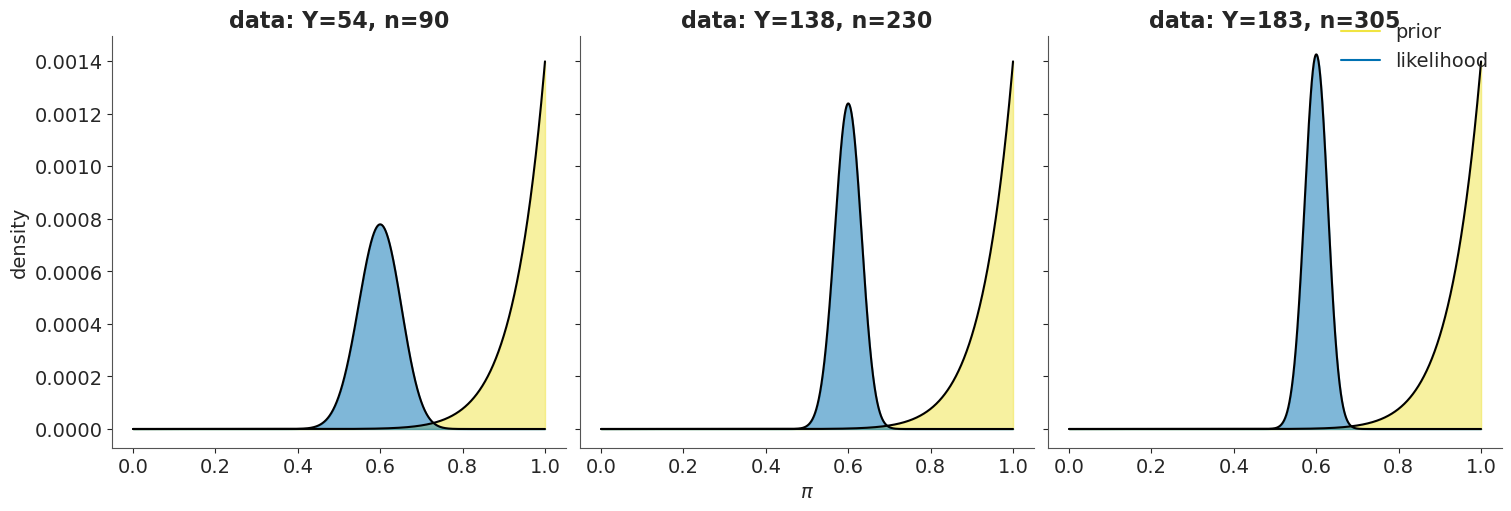

In [40]:
# 定义不同的二项分布参数 (y, n)
params = [(54, 90), (138, 230), (183, 305)]

# 创建一个包含三个子图的画布
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
x = np.linspace(0, 1, 10000)

# 设置 Beta 分布的参数
alpha_ = 14
beta_ = 1

# 计算 Beta 分布的概率密度函数值并进行归一化
pdf_values = beta.pdf(x, alpha_, beta_) / np.sum(beta.pdf(x, alpha_, beta_))

# 循环遍历不同的参数组合 (y, n)
for i, (y, n) in enumerate(params):
    # 计算二项分布的似然值并进行归一化
    likelihood_value = st.binom.pmf(y, n, x) / np.sum(st.binom.pmf(y, n, x))

    # 绘制先验分布的线图
    axes[i].plot(x, pdf_values, color="black", label="prior")
    axes[i].fill_between(x, pdf_values, color="#f0e442", alpha=0.5)
    
    # 绘制似然值的线图
    axes[i].plot(x, likelihood_value, color="black", label="likelihood")
    axes[i].fill_between(x, likelihood_value, color="#0071b2", alpha=0.5)

    # 设置子图标题
    axes[i].set_title(f'data: Y={y}, n={n}')

# 设置 x 和 y 轴标签
axes[1].set_xlabel('$\pi$')
axes[0].set_ylabel('density')

# 创建自定义图例
custom_lines = [Line2D([], [], color="#f0e442"),
                Line2D([], [], color="#0071b2")]
        
# 将图例放置在子图外部的右上角
fig.legend(custom_lines, ['prior', 'likelihood'], loc='outside upper right', bbox_to_anchor=(1, 1))

# 移除图的上、右边框线
sns.despine()



🤔思考时间：  
谁的后验分布受到数据的影响更大？

**似然对后验的影响**  


我们可以发现，虽然三种似然分布的均值都是0.60，但是随着样本量增大，似然的分布越窄，反映的信息越集中。  

*注意：在似然中，y轴为$f(y|\pi)$，表示在特定的$\pi$值下产生当前数据的相对可能性。*  

* 在小红的似然函数中，“90个试次中有54次判断为正确”的结果在$\pi$为0.4-0.8时，都有可能出现。  

* 但在小绿的似然函数中，“305个试次中有183次判断为正确”的结果只在$\pi$为0.5-0.7时，才有可能出现。  

* 换言之，小绿的似然函数直接将pi的可能取值缩小到一个更小的范围  


**当似然反映的信息越集中时，它对后验的影响越大**  


-----------------------------  

同样的，我们可以使用公式快速计算出后验beta分布中的参数，并画图  

<center>  

| Analyst | Data                                  | Posterior                             |
|---------|---------------------------------------|---------------------------------------|
| 小红    | 90 个试次，54 次正确                   | $\text{Beta}(\alpha + 54, \beta + 36)$|
| 小蓝    | 230 个试次，138 次正确                | $\text{Beta}(\alpha + 138, \beta + 92)$|
| 小绿    | 305 个试次，183 次正确                | $\text{Beta}(\alpha + 183, \beta + 122)$|

</center>

<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
/var/folders/yk/78rqxlxn4pz_rsb5_31xvh340000gn/T/ipykernel_19508/2626910057.py:44: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_xlabel('$\pi$')


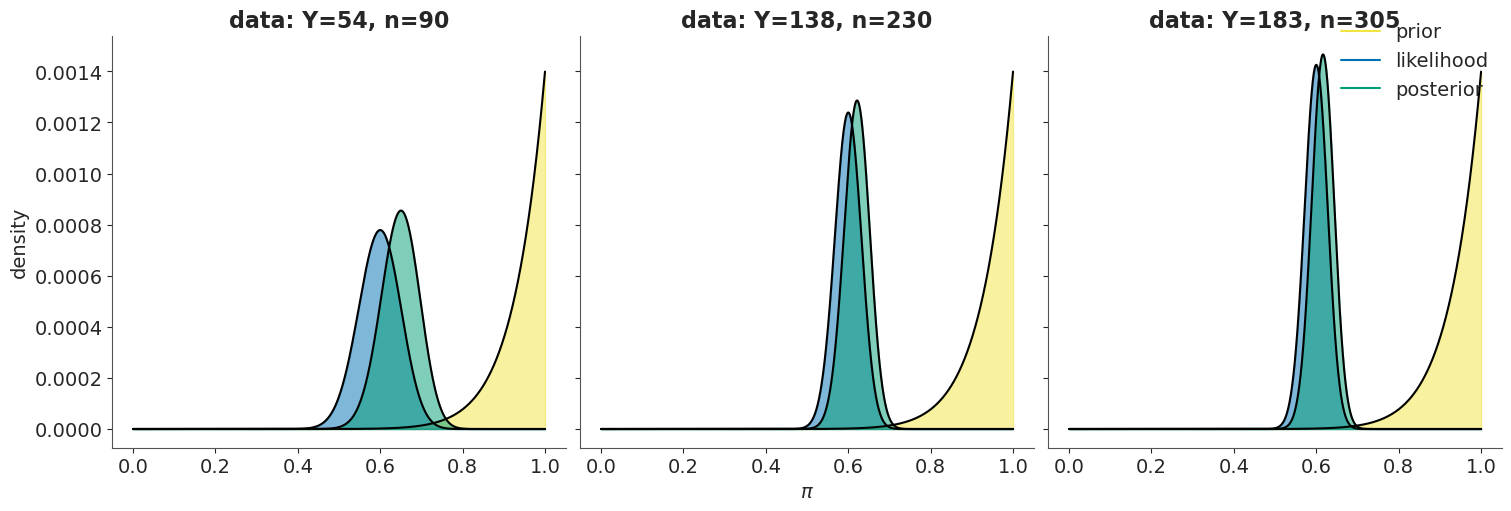

In [41]:
# 定义不同的二项分布参数 (y, n)
params = [(54, 90), (138, 230), (183, 305)]

# 创建一个包含三个子图的画布
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
x = np.linspace(0, 1, 10000)

# 设置 Beta 分布的参数
alpha_ = 14
beta_ = 1

# 计算 Beta 分布的概率密度函数值
pdf_values = beta.pdf(x, alpha_, beta_)

# 循环遍历不同的参数组合 (y, n)
for i, (y, n) in enumerate(params):
    # 计算二项分布的似然值
    likelihood_value = st.binom.pmf(y, n, x)
    
    # 计算后验概率
    posterior = pdf_values * likelihood_value
    
    # 归一化后验概率、先验概率和似然值
    posterior /= np.sum(posterior)
    pdf_values /= np.sum(pdf_values)
    likelihood_value /= np.sum(likelihood_value)

    # 绘制先验分布的线图
    axes[i].plot(x, pdf_values, color="black", label="prior")
    axes[i].fill_between(x, pdf_values, color="#f0e442", alpha=0.5)
    
    # 绘制似然值的线图
    axes[i].plot(x, likelihood_value, color="black", label="likelihood")
    axes[i].fill_between(x, likelihood_value, color="#0071b2", alpha=0.5)
    
    # 绘制后验概率的线图
    axes[i].plot(x, posterior, color="black", label="posterior")
    axes[i].fill_between(x, posterior, color="#009e74", alpha=0.5)

    # 设置子图标题
    axes[i].set_title(f'data: Y={y}, n={n}')

# 设置 x 和 y 轴标签
axes[1].set_xlabel('$\pi$')
axes[0].set_ylabel('density')

# 创建自定义图例
custom_lines = [Line2D([], [], color="#f0e442"),
                Line2D([], [], color="#0071b2"),
                Line2D([], [], color="#009e74")]
        
# 将图例放置在子图外部的右上角
fig.legend(custom_lines, ['prior', 'likelihood', 'posterior'], loc='outside upper right', bbox_to_anchor=(1, 1))

# 移除图的上、右边框线
sns.despine()

### Sequential analysis: Evolving with data 


现在，我们探讨了随着更多数据的到来，数据的影响力逐渐增加，先验观念的影响力逐渐减小，从而影响后验理解的演进。  

我们再次回顾一下**随机点运动任务**的例子。在这个任务中，参与者需要判断屏幕上随机移动的点的主要运动方向（例如，向左或向右）。
任务的难度可以根据**一致性水平（percent coherence）**来调整，表示点的运动方向有多明确。
比如说，一致性为 60% 意味着 60% 的点朝着同一方向移动，其余 40% 是随机的。 

初始的先验分布反映了我们对参与者决策能力的初始信念，而随着数据逐步积累，后验分布逐渐反映出数据本身的影响力。

#### 步骤：
1. **初始先验分布**：
    - 我们可能对参与者的正确率 $\pi$ 一无所知，因此假设一个均匀的 Beta 先验 $\text{Beta}(1, 1)$。
    - 这表示所有正确率值在 0 和 1 之间都是等可能的。
    
    $$ 
    \pi \sim \text{Beta}(1, 1)
    $$
   
2. **逐步更新的过程**：
    - 在每一轮实验中，参与者会进行多个试次，例如，假设一轮有 10 个试次，参与者其中 6 次判断正确，则通过贝叶斯公式更新后得到后验分布：

    $$
    \pi | (Y = 6) \sim \text{Beta}(1 + 6, 1 + 4) = \text{Beta}(7, 5)
    $$

    - 然后，参与者完成了 20 个试次，正确了 12 次，则再次更新后得到新的后验分布：

    $$
    \pi | (Y = 12) \sim \text{Beta}(7 + 12, 5 + 8) = \text{Beta}(19, 13)
    $$

     - 接下来，参与者又完成了 30 个试次，正确了 18 次，则再次更新后得到新的后验分布：

    $$
    \pi | (Y = 18) \sim \text{Beta}(19 + 18, 13 + 12) = \text{Beta}(37, 25)
    $$

    - 随着更多数据进入，后验分布逐渐集中，反映了更可靠的正确率估计。

随着实验进行，我们能够通过顺序贝叶斯分析逐步更新对参与者正确率的推断。
最初的先验可能有很大的不确定性，但随着试次的增加，后验分布逐渐变得更加集中，越来越反映真实的正确率。
最终，数据的影响力占据主导地位，先验观念的影响逐渐减弱。

**顺序贝叶斯分析(sequential Bayesian analysis)**  


| 更新步骤  | 试次数 | 正确次数 | 先验分布              | 后验分布              |
|-----------|--------|----------|-----------------------|-----------------------|
| 初始先验  | NA     | NA       | Beta(1, 1)             | NA                    |
| 第一次更新| 10     | 6        | Beta(1, 1)             | Beta(7, 5)            |
| 第二次更新| 20     | 12       | Beta(7, 5)             | Beta(19, 13)          |
| 第三次更新| 30     | 18       | Beta(19, 13)           | Beta(37, 25)          |


COMMENT：要不要加一张可视化的图

**顺序贝叶斯分析（又称贝叶斯学习）**  

- 在顺序贝叶斯分析中，随着新数据的到来，后验模型会逐步更新。  
- 每一份新数据都会使前一次后验模型（反映我们在观察到这些数据之前的理解）成为新的先验模型。  


COMMENT:这里需要替换动图

贝叶斯框架的一个最强大的特性就是能够随着新数据的到来而演进。这种顺序分析还维持了两个基本的且符合常识的特性。  

- 首先，最终的后验模型是数据顺序不变的，即它不受我们观察数据顺序的影响。
- 例如，假设我们在**随机点运动任务**中，以第三次的观测为先验，再依次使用第一次和第二次的观测来更新模型。虽然数据的顺序不同，但最终的推断结果（后验分布）是相同的。
  - 第三次 $Y = 30$，$n = 18$
  - 第二次 $Y = 20$，$n = 12$
  - 第一次 $Y = 10$，$n = 6$
- 虽然数据的顺序不同，但我们对 $\pi$ 的推断最终会收敛到相同的后验分布——$\text{Beta}(43, 29)$。


| 更新步骤  | 试次数 | 正确次数 | 先验分布              | 后验分布              |
|-----------|--------|----------|-----------------------|-----------------------|
| 第三次更新| 30     | 18       | Beta(1, 1)             | Beta(19, 13)          |
| 第二次更新| 20     | 12       | Beta(19, 13)           | Beta(37, 25)          |
| 第一次更新| 10     | 6        | Beta(37, 25)           | Beta(43, 29)          |

在这个例子中，尽管我们从第三次观测开始，然后依次更新数据，最终的后验分布仍然是 $\text{Beta}(43, 29)$，与我们按照顺序逐步评估数据所得到的结果相同。

顺序分析的第二个基本特性是，最终的后验只依赖于累积的数据。
- 例如，在这三次的随机点运动任务中，共有 $n = 10 + 20 + 30 = 60$ 次试次，其中 $Y = 6 + 12 + 18 = 36$ 次判断正确。
- 初始先验分布是 $\text{Beta}(1, 1)$，通过累积数据可以直接计算出后验分布为：

$$
\pi | (Y = 36) \sim \text{Beta}(1 + 36, 1 + 60 - 36) = \text{Beta}(37, 25)
$$

因此，不论我们是逐步更新还是一次性计算，结果最终都会收敛到相同的后验分布 $\text{Beta}(37, 25)$。

**结论：**
- **顺序不变性**：后验分布不受数据输入的顺序影响，只要数据总量相同，最终结果是一致的。
- **累积数据依赖性**：我们可以逐步或一次性评估数据，后验分布只依赖于观测数据的总量。

### 补充：贝叶斯顺序分析的两大特征的数学证明

在之前的讨论中，我们通过实例展示了**数据顺序不变性**的特点。接下来，我们将为该特性在所有贝叶斯模型中的适用性进行数学证明。

#### 数据顺序不变性

定义 $\theta$ 为感兴趣的任意参数，其先验概率密度函数为 $f(\theta)$。无论我们先观察数据点 $y_1$ 然后观察 $y_2$，还是先观察 $y_2$ 再观察 $y_1$，最终的后验分布都是相同的，即：

$$
f(\theta \mid y_1, y_2) = f(\theta \mid y_2, y_1)
$$

同样，无论我们一次性观察所有数据，还是按顺序逐步观察数据，最终的后验分布都不受影响。

#### 证明

为了证明这一点，我们首先考虑通过顺序观察数据 $y_1$ 和 $y_2$ 来构建的后验概率密度函数 $f(\theta \mid y_1, y_2)$。  
在这个过程中，后验概率的演化可以分两步进行：

1. **第一步**：我们首先从原始先验分布 $f(\theta)$ 和基于第一个数据点 $y_1$ 的似然函数 $L(\theta \mid y_1)$ 构建后验分布：

   $$
   f(\theta \mid y_1) = \frac{f(\theta) L(\theta \mid y_1)}{f(y_1)}
   $$

   其中，$f(y_1)$ 是归一化常数，用于确保后验分布的积分为 1。

2. **第二步**：在观察到新的数据 $y_2$ 后，我们使用 $f(\theta \mid y_1)$ 作为先验，并根据数据 $y_2$ 更新模型：

   $$
   f(\theta \mid y_2, y_1) = \frac{f(\theta \mid y_1) L(\theta \mid y_2)}{f(y_2)}
   $$

   代入第一步中的 $f(\theta \mid y_1)$，得到：

   $$
   f(\theta \mid y_2, y_1) = \frac{\frac{f(\theta) L(\theta \mid y_1)}{f(y_1)} L(\theta \mid y_2)}{f(y_2)}
   $$

   化简后：

   $$
   f(\theta \mid y_2, y_1) = \frac{f(\theta) L(\theta \mid y_1) L(\theta \mid y_2)}{f(y_1) f(y_2)}
   $$

类似地，以相反的顺序，先观察 $y_2$ 然后观察 $y_1$，我们得到同样的后验分布：

$$
f(\theta \mid y_1, y_2) = \frac{f(\theta) L(\theta \mid y_2) L(\theta \mid y_1)}{f(y_2) f(y_1)}
$$

因此，后验分布 $f(\theta \mid y_1, y_2)$ 与 $f(\theta \mid y_2, y_1)$ 相同，证明了数据的顺序不会影响最终的后验分布。

#### 一次性观察数据 vs 顺序观察数据

不仅数据的顺序不影响后验分布，观察数据的方式（一次性或逐步）也不影响最终结果。为此，假设我们从先验分布 $f(\theta)$ 开始，并同时观察数据 $(y_1, y_2)$。假设这些数据点在无条件和有条件下是独立的，那么：

$$
f(y_1, y_2) = f(y_1) f(y_2)
\quad \text{和} \quad 
f(y_1, y_2 \mid \theta) = f(y_1 \mid \theta) f(y_2 \mid \theta)
$$

因此，从同时观察数据 $(y_1, y_2)$ 得到的后验分布为：

$$
f(\theta \mid y_1, y_2) = \frac{f(\theta) f(y_1, y_2 \mid \theta)}{f(y_1, y_2)}
$$

代入条件独立性假设：

$$
f(\theta \mid y_1, y_2) = \frac{f(\theta) f(y_1 \mid \theta) f(y_2 \mid \theta)}{f(y_1) f(y_2)}
$$

这与顺序观察数据所得的后验分布相同：

$$
f(\theta \mid y_1, y_2) = \frac{f(\theta) L(\theta \mid y_1) L(\theta \mid y_2)}{f(y_1) f(y_2)}
$$

因此，不论是一次性观察所有数据，还是按顺序逐步观察数据，最终的后验分布是相同的。

---

**总结**：

贝叶斯顺序分析的两大特性——**数据顺序不变性**和**累积数据依赖性**——可以通过以上数学证明得到验证。无论数据是顺序观察还是一次性观察，或者数据顺序如何变化，最终的后验分布总是不变的。这一特性使得贝叶斯分析在处理动态和实时数据时具有极大的灵活性和可靠性。

### Striking a balance between the prior & data

**不同先验+不同似然产生的后验分布**  

我们已经看到不同的先验和不同的数据对后验分布的影响  

**实际上，后验分布是两者间的平衡。**  

我们可以将不同的先验和似然组合在一起，观察后验的变化

<>:52: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\p'
/var/folders/yk/78rqxlxn4pz_rsb5_31xvh340000gn/T/ipykernel_19508/3328315750.py:52: SyntaxWarning: invalid escape sequence '\p'
  fig.supxlabel('$\pi$')
/var/folders/yk/78rqxlxn4pz_rsb5_31xvh340000gn/T/ipykernel_19508/3328315750.py:64: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


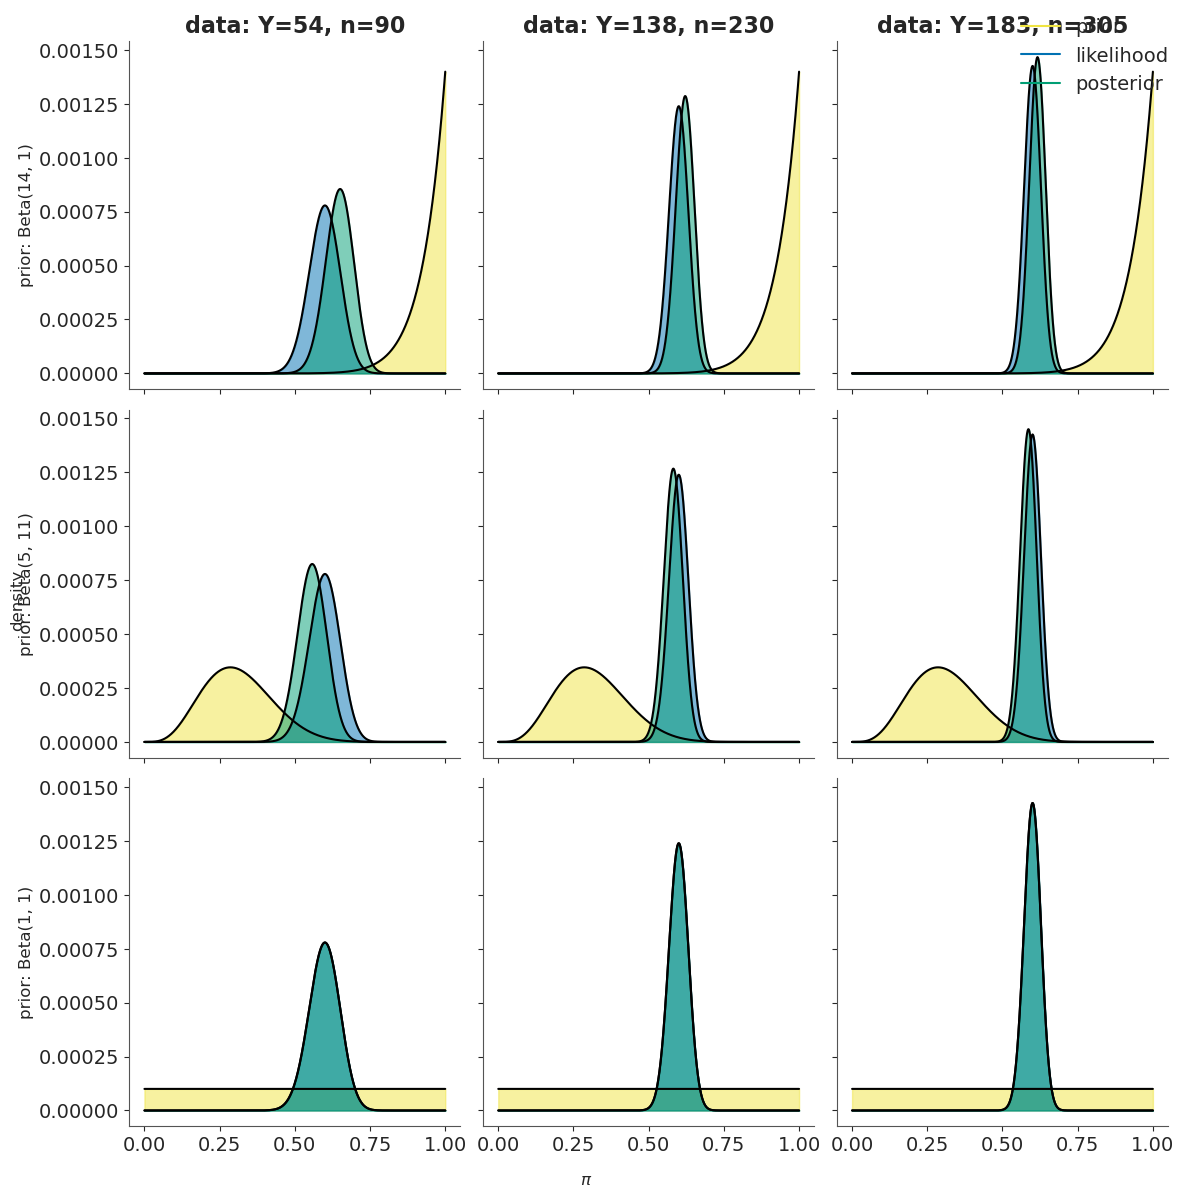

In [ ]:
# 生成一系列 pi 值
x = np.linspace(0, 1, 10000)

# 创建一个 DataFrame 以存储 pi 值和后验分布
df = pd.DataFrame({'pi': x})

# 定义似然值
likelihoods = [(54, 90), (138, 230), (183, 305)]

# 定义先验分布
priors = [(14, 1), (5, 11), (1, 1)]

# 创建一个 3x3 的子图网格，用于绘制九个图
fig, axs = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)

# 计算并绘制所有似然值和先验分布组合的后验分布
for i, prior_params in enumerate(priors):
    for j, lik_params in enumerate(likelihoods):

        prior_name = f'prior_{prior_params[0]}_{prior_params[1]}'
        lik_name = f'lik_{lik_params[0]}_{lik_params[1]}'
        posterior_name = f'posterior_{lik_params[0]}_{lik_params[1]}_{prior_params[0]}_{prior_params[1]}'
        
        # 计算先验分布
        df[prior_name] = df['pi'].apply(lambda x: beta.pdf(x, prior_params[0], prior_params[1]))

        # 计算似然值
        df[lik_name] = df['pi'].apply(lambda x: st.binom.pmf(lik_params[0], lik_params[1], x))

        # 计算后验分布通过将似然值和先验分布相乘
        df[posterior_name] = df[lik_name] * df[prior_name]

        # 对似然值、先验分布和后验分布进行归一化
        df[lik_name] /= df[lik_name].sum()
        df[prior_name] /= df[prior_name].sum()
        df[posterior_name] /= df[posterior_name].sum()
        
        # 绘制先验分布、归一化似然值和后验分布的密度图
        axs[i, j].plot(df['pi'], df[prior_name], label='prior', color='black')
        axs[i, j].fill_between(df['pi'], df[prior_name], color="#f0e442", alpha=0.5)

        axs[i, j].plot(df['pi'], df[lik_name], label='likelihood', color='black')
        axs[i, j].fill_between(df['pi'], df[lik_name], color="#0071b2", alpha=0.5)

        axs[i, j].plot(df['pi'], df[posterior_name], label='posterior', color='black')
        axs[i, j].fill_between(df['pi'], df[posterior_name], color="#009e74", alpha=0.5)

        axs[0, j].set_title(f'data: Y={lik_params[0]}, n={lik_params[1]}')

    axs[i, 0].set_ylabel(f'prior: Beta{prior_params}', fontsize=12)

fig.supxlabel('$\pi$')
fig.supylabel('density')

# 创建自定义图例
custom_lines = [Line2D([], [], color="#f0e442"),
                Line2D([], [], color="#0071b2"),
                Line2D([], [], color="#009e74")]
        
# 将图例放置在图的右上角
fig.legend(custom_lines, ['prior', 'likelihood', 'posterior'], loc='outside upper right', bbox_to_anchor=(1, 1))

# 调整子图之间的间距
plt.tight_layout()

# 移除图的上、右边框线
sns.despine()



* 从左往右，数据的试次从90增加到305，似然的分布越集中，对后验的影响也越来越大  

* 从上往下，先验分布从信息型(informative prior)变为模糊型(vague prior)，先验分布对后验分布的影响也就越来越小  

* 而最后一列告诉我们，无论不同的人对先验的差异有多大，只要似然的分布够集中，即数据提供的信息足够丰富，那么后验分布主要受到来自数据的影响，不同人的后验分布也并不会相差太大。

同时，我们探讨了后验模型在先验模型和数据之间的平衡。总的来说，我们观察到以下趋势：  

- 先验影响：先验越不模糊、越具有信息量，即我们对先验越有确定性，先验对后验的影响就越大。  
- 数据影响：我们拥有的数据越多，数据对后验的影响就越大。因此，即使具有不同的先验，如果两次测量的数据充足并且相似，那么他们的后验结果会非常相似。  
- 此外，我们还看到在顺序贝叶斯分析中，随着越来越多的数据的出现，我们逐步更新后验模型。这个后验的最终结果不受观察数据的顺序（即后验对数据的顺序不变）或者是一次性观察数据还是逐步观察数据的影响。

练习 4.1（将先验与描述配对）。  

下面列出了五种不同的π的先验模型。  
请用以下描述之一标记每个先验：有些偏向π < 0.5，有些强烈偏向π < 0.5，有些将π置于0.5中心，有些偏向π > 0.5，有些强烈偏向π > 0.5。  
- a) Beta(1.8,1.8)  
- b) Beta(3,2)  
- c) Beta(1,10)  
- d) Beta(1,3)  
- e) Beta(17,2)  

练习 4.2（将图形与代码配对）。  

下面的绘图函数更可能使用了哪些参数生成了下面的图形？  
![](https://www.bayesrulesbook.com/bookdown_files/figure-html/unnamed-chunk-142-1.png)  
- a) alpha = 2, beta = 2, y = 8, n = 11  
- b) alpha = 2, beta = 2, y = 3, n = 11  
- c) alpha = 3, beta = 8, y = 2, n = 6  
- d) alpha = 3, beta = 8, y = 4, n = 6  
- e) alpha = 3, beta = 8, y = 2, n = 4  
- f) alpha = 8, beta = 3, y = 2, n = 4

In [ ]:
# 导入数据加载和处理包：pandas
import pandas as pd
# 导入数字和向量处理包：numpy
import numpy as np
# 导入基本绘图工具：matplotlib
import matplotlib.pyplot as plt
# 导入高级绘图工具 seaborn 为 sns
import seaborn as sns
# 导入统计建模工具包 scipy.stats 为 st
import scipy.stats as st 


#---------------------------------------------------------------------------
#                            请填入 Beta 分布参数，alpha 和 beta
#---------------------------------------------------------------------------
# 设置 Beta 分布参数
a = ...     # alpha
b = ...     # beta

#---------------------------------------------------------------------------
#                            请填入观测数据 y 和 n
#---------------------------------------------------------------------------
y = ...     # y 代表支持数
n = ...     # n 代表总人数


# 设置 x 轴范围 [0,1]
x = np.linspace(0,1,10000)
# 形成先验分布 
prior = st.beta.pdf(x,a,b)/np.sum(st.beta.pdf(x,a,b))
# 形成似然
likelihood = st.binom.pmf(y,n,x)

# 计算后验
unnorm_posterior = prior * likelihood                  # 计算分子
posterior = unnorm_posterior/np.sum(unnorm_posterior)  # 结合分母进行计算
likelihood = likelihood /np.sum(likelihood)            # 为了方便可视化，对似然进行类似后验的归一化操作 

# 绘图
plt.plot(x,posterior, color="#009e74", alpha=0.5, label="posterior")
plt.plot(x,likelihood, color="#0071b2", alpha=0.5, label="likelihood")
plt.plot(x,prior, color="#f0e442", alpha=0.5, label="prior")
plt.legend()
plt.xlabel("Michelle's support ratio $\pi$")
plt.fill_between(x, prior, color="#f0e442", alpha=0.5)
plt.fill_between(x, likelihood, color="#0071b2", alpha=0.5)
plt.fill_between(x, posterior, color="#009e74", alpha=0.5)
sns.despine()

### 💐Bonus：使用数学公式证明，后验确实利用了来自先验和似然的信息

（* 注：以下涉及的公式包含上一节bonus中的内容）  

由于后验分布属于beta分布，因此它的平均值可以写成：  

$$  
E(\pi | Y=y)  = \frac{\alpha + y}{\alpha + \beta + n}  .  
$$  

我们可以将$\frac{\alpha + y}{\alpha + \beta + n}$拆成以下两部分  

$$  
E(\pi | Y=y)  
= \frac{\alpha}{\alpha + \beta + n} + \frac{y}{\alpha + \beta + n}  \\  
= \frac{\alpha}{\alpha + \beta + n}\cdot\frac{\alpha + \beta}{\alpha + \beta} + \frac{y}{\alpha + \beta + n}\cdot\frac{n}{n}  \\  
= \frac{\alpha + \beta}{\alpha + \beta + n}\cdot\frac{\alpha}{\alpha + \beta} + \frac{n}{\alpha + \beta + n}\cdot\frac{y}{n}  \\  
= \frac{\alpha + \beta}{\alpha + \beta + n}\cdot E(\pi) + \frac{n}{\alpha + \beta + n}\cdot\frac{y}{n}  .  \\  
$$  

$$  
y:success trial,\; n:total trials \\  
y/n表示观察到的数据比例  
$$  

且，  
$$  
\frac{\alpha + \beta}{\alpha + \beta + n} + \frac{n}{\alpha + \beta + n} = 1.  

$$  


可以看到，后验均值可以被分解为  
<center>  
权重*先验均值 + 权重*数据  
</center>  

那么，当数据越多，即n越大时，先验的权重就会更小，接近0；而数据的权重就会越大  

因此，后验正是权衡了来自先验和似然的信息